In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd

In [2]:
# change working directory
os.chdir('/usr/users/papantonis1/stripeDiff-master')

In [3]:
pd.set_option("display.max_columns", None)

ctrl_files = sorted(glob.glob('in_control_not_eed_chr*_stripes_with_p.txt'))
eed_files = sorted(glob.glob('in_eed_not_control_chr*_stripes_with_p.txt'))

def concat_stripes(files, label):
    dfs = []
    for f in files:
        df = pd.read_csv(f, sep='\t', header=0)
        df['chr'] = f.split('_')[4].replace('stripes', '').replace('with', '').replace('p.txt','').replace('.txt','')
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    out['class'] = label
    return out

ctrl_stripes = concat_stripes(ctrl_files, 'control')
eed_stripes = concat_stripes(eed_files, 'eed')

/tmp/ipykernel_4054909/4239468051.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(dfs, ignore_index=True)
/tmp/ipykernel_4054909/4239468051.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(dfs, ignore_index=True)


In [6]:
len(ctrl_stripes)

2476

In [14]:
# No. of stripes in control only - 2476
# No. of stripes in cpi only - 2283

In [7]:
len(eed_stripes)

2283

In [8]:
ctrl_sig = ctrl_stripes[ctrl_stripes['strap.pValue.sample1'] < 0.1]
eed_sig = eed_stripes[eed_stripes['strap.pValue.sample2'] < 0.1]

In [9]:
len(ctrl_sig)

21

In [10]:
len(eed_sig)

296

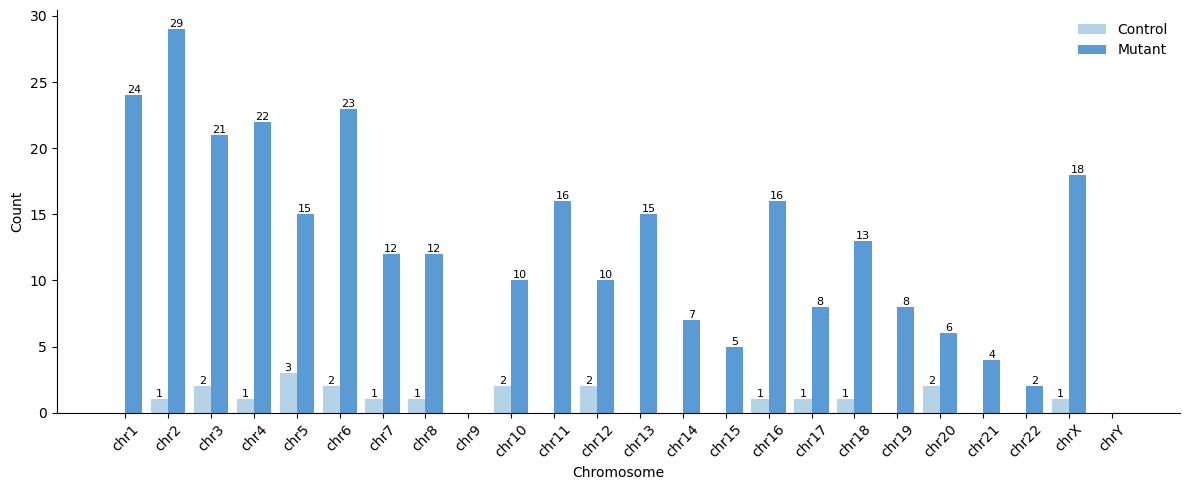

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ctrl_counts = ctrl_sig['chrom'].value_counts().sort_index()
eed_counts = eed_sig['chrom'].value_counts().sort_index()
chrom_order = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
ctrl_vals = [ctrl_counts.get(ch, 0) for ch in chrom_order]
eed_vals = [eed_counts.get(ch, 0) for ch in chrom_order]

x = np.arange(len(chrom_order))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
bar1 = ax.bar(x - width/2, ctrl_vals, width, label="Control", color="#b5d3e7", alpha=1)
bar2 = ax.bar(x + width/2, eed_vals, width, label="Mutant", color="#5b9bd5", alpha=1)

for b in bar1:
    if b.get_height() > 0:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(b.get_height())}",
                ha="center", va="bottom", fontsize=8)
for b in bar2:
    if b.get_height() > 0:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(b.get_height())}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(chrom_order, rotation=45)
ax.set_xlabel("Chromosome")
ax.set_ylabel("Count")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
strengthened = (df['p.chip'] < 0.05) & ((df['logFoldChange.sample2'] - df['logFoldChange.sample1']) > 0)
weakened    = (df['p.chip'] < 0.05) & ((df['logFoldChange.sample2'] - df['logFoldChange.sample1']) < 0)